# Data retrieval

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Survivor rate of passengers in titanic crash 
# Target = Survived column 
df = pd.read_csv(r'titanic_git.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Data cleaning

### Irrelevant columns

In [4]:
# Instruction from author - Delete Passenger, Name, SibSp, Parch, Ticket, Cabin and Embarked
df.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin', 'Embarked'], axis=1, inplace=True)
df

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,NaN,23.4500
889,1,1,male,26.0,30.0000


### Missing values

In [5]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
Fare          0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
df

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
885,0,3,female,39.0,29.1250
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
889,1,1,male,26.0,30.0000


In [8]:
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
dtype: int64

### Outliers

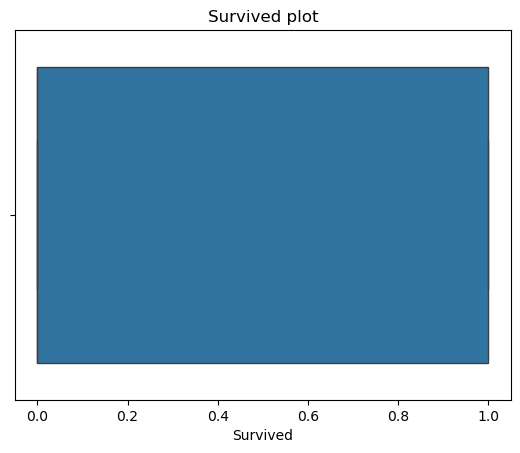

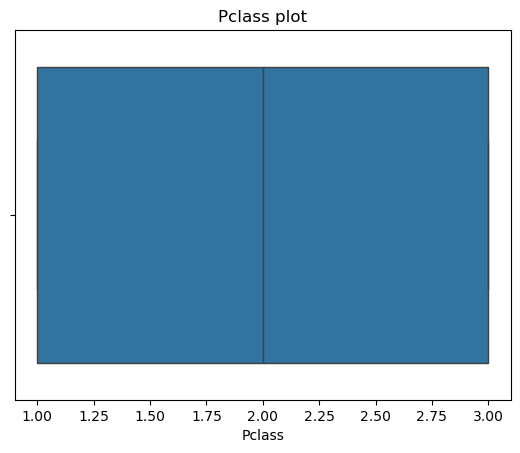

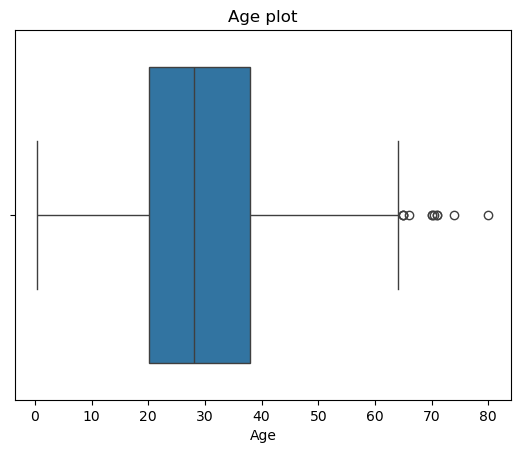

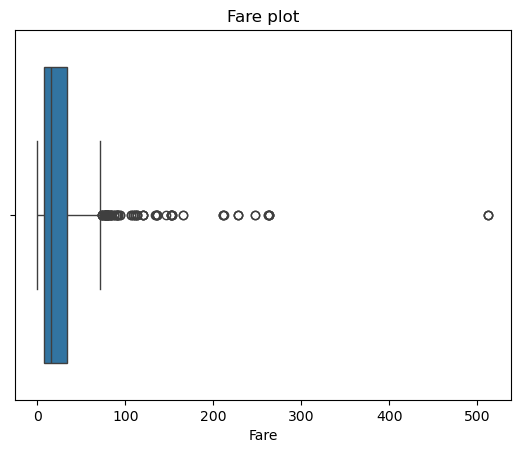

In [9]:
num_cols = ['Survived','Pclass','Age','Fare']

for col in num_cols:
    sns.boxplot(df[col], orient='h')
    plt.title(f'{col} plot')
    plt.show()

In [10]:
from scipy.stats.mstats import winsorize

# df['Age'] = winsorize(df['Age'], limits=[0.05,0.05])
df['Fare'] = winsorize(df['Fare'], limits=[0.02,0.02])

In [11]:
# Calculate age quantile thresholds
age_lower = df['Age'].quantile(0.05)
age_upper = df['Age'].quantile(0.95)

# Drop rows where Age is an outlier
df = df[(df['Age'] >= age_lower) & (df['Age'] <= age_upper)]
df

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
885,0,3,female,39.0,29.1250
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
889,1,1,male,26.0,30.0000


### Duplicated entries

In [12]:
df.duplicated().sum()

np.int64(44)

In [13]:
df.drop_duplicates(inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_4140\3006716147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


# Data preprocessing

In [14]:
df

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
883,0,2,male,28.0,10.5000
885,0,3,female,39.0,29.1250
887,1,1,female,19.0,30.0000
889,1,1,male,26.0,30.0000


### Label Encoding 

In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])

C:\Users\User\AppData\Local\Temp\ipykernel_4140\3867145633.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = le_sex.fit_transform(df['Sex'])


### Standardization

In [17]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,605.000000,605.000000,605.000000,605.000000,605.000000
mean,0.414876,2.242975,0.614876,29.328099,33.131625
std,0.493108,0.845011,0.487027,11.723648,41.857796
min,0.000000,1.000000,0.000000,4.000000,6.750000
25%,0.000000,1.000000,0.000000,21.000000,8.050000
50%,0.000000,3.000000,1.000000,28.000000,15.550000
75%,1.000000,3.000000,1.000000,37.000000,34.375000
max,1.000000,3.000000,1.000000,56.000000,211.500000


In [18]:
std_cols = df.columns.drop(['Survived','Sex'])

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
ss = StandardScaler()
df[std_cols] = ss.fit_transform(df[std_cols]).round(2)
df

C:\Users\User\AppData\Local\Temp\ipykernel_4140\3616101627.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[std_cols] = ss.fit_transform(df[std_cols]).round(2)


,Survived,Pclass,Sex,Age,Fare
0,0,0.90,1,-0.63,-0.62
1,1,-1.47,0,0.74,0.91
2,1,0.90,0,-0.28,-0.60
3,1,-1.47,0,0.48,0.48
4,0,0.90,1,0.48,-0.60
...,...,...,...,...,...
883,0,-0.29,1,-0.11,-0.54
885,0,0.90,0,0.83,-0.10
887,1,-1.47,0,-0.88,-0.07
889,1,-1.47,1,-0.28,-0.07


# Data splitting

In [21]:
from sklearn.model_selection import train_test_split

In [45]:
y = df['Survived']
X = df.drop('Survived', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=58, stratify=y, test_size=0.30)

In [46]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(423, 4) (423,) (182, 4) (182,)


In [47]:
print(y.value_counts())
print()
print(y.value_counts(normalize=True))

Survived
0    354
1    251
Name: count, dtype: int64

Survived
0    0.585124
1    0.414876
Name: proportion, dtype: float64


# Model building

In [48]:
from sklearn import tree

In [49]:
model = tree.DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Evaluation

In [50]:
y_pred = model.predict(X_test)

In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

In [52]:
acc = model.score(X_test, y_test)
pre = precision_score(y_test, y_pred)
re = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)

In [53]:
print(f"Accuracy Score       : {acc:.4f}")
print(f"Precision Score      : {pre:.4f}")
print(f"Recall Score         : {re:.4f}")
print(f"F1 Score             : {f1:.4f}")
print("\nClassification Report:\n")
print(cr)

Accuracy Score       : 0.7747
Precision Score      : 0.7160
Recall Score         : 0.7632
F1 Score             : 0.7389

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.78      0.80       106
           1       0.72      0.76      0.74        76

    accuracy                           0.77       182
   macro avg       0.77      0.77      0.77       182
weighted avg       0.78      0.77      0.78       182

